In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7,7)
plt.rcParams["font.size"] = 12

## Define the Vector and the New Basis

The first step is to define the vector whose coordinates we want to change.

The vector is currently expressed in the **standard basis**, where the basis vectors are

$$
\mathbf{e}_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\mathbf{e}_2=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

We then define a new basis consisting of two linearly independent vectors,

$$
\mathbf{b}_1=
\begin{bmatrix}
2\\
1
\end{bmatrix},
\qquad
\mathbf{b}_2=
\begin{bmatrix}
-1\\
1
\end{bmatrix}.
$$

The objective is to express the same geometric vector using this new basis. That is, **the vector itself does not change**. Only the way we describe it changes.

Our original vector is

$$
\mathbf{v}=
\begin{bmatrix}
4\\
3
\end{bmatrix},
$$

which means **3 units along the standard x-axis** and **3 units along the standard y-axis**.

After changing the basis, the same vector is represented by the coordinates

$$
[\mathbf{v}]_B=
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

This does **not** mean that the vector has changed. Instead, it means that the vector can now be written as

$$
\mathbf{v}=2\mathbf{b}_1+1\mathbf{b}_2.
$$

In other words, instead of saying

- Move **3 units along the x-axis** and **3 units along the y-axis**,

we now say

- Move **2 copies of** $\mathbf{b}_1$ and **1 copy of** $\mathbf{b}_2$.

Both descriptions represent the **same geometric vector**.


In [2]:
# -------------------------
# Standard basis vector
# -------------------------

v = np.array([3,3])

# -------------------------
# New basis vectors
# -------------------------

b1 = np.array([2,1])
b2 = np.array([-1,1])

print("Vector (standard basis):")
print(v)

print("\nNew Basis")

print("b1 =", b1)
print("b2 =", b2)

Vector (standard basis):
[3 3]

New Basis
b1 = [2 1]
b2 = [-1  1]


The new basis vectors are arranged as the **columns** of a matrix called the **basis matrix**.

$$
P=
\begin{bmatrix}
| & |\\
\mathbf{b}_1 & \mathbf{b}_2\\
| & |
\end{bmatrix}
$$

Before using this matrix for a change of basis, we verify that it is invertible by computing its determinant. If the determinant is non-zero, the basis vectors are linearly independent and form a valid basis.

In [3]:
P = np.column_stack((b1,b2))

print("Basis Matrix P\n")
print(P)

det = np.linalg.det(P) #Computes the determinant of the basis matrix

print("\nDeterminant =",det)

if abs(det) < 1e-10:
    raise ValueError("The chosen vectors are NOT a basis.")

print("\nThe vectors form a valid basis.")

Basis Matrix P

[[ 2 -1]
 [ 1  1]]

Determinant = 2.9999999999999996

The vectors form a valid basis.


Suppose the coordinates of the vector in the new basis are

$$
\begin{bmatrix}
a\\
b
\end{bmatrix}.
$$

Then the original vector can be written as

$$
P
\begin{bmatrix}
a\\
b
\end{bmatrix}
=
\mathbf{v}.
$$

Our goal is to determine the unknown coordinates

$$
\begin{bmatrix}
a\\
b
\end{bmatrix}.
$$

Just like solving an algebraic equation, we multiply both sides by the inverse of the basis matrix:

$$
P^{-1}P
\begin{bmatrix}
a\\
b
\end{bmatrix}
=
P^{-1}\mathbf{v}.
$$

Since

$$
P^{-1}P=I,
$$

where \(I\) is the identity matrix, we obtain

$$
\begin{bmatrix}
a\\
b
\end{bmatrix}
=
P^{-1}\mathbf{v}.
$$

$$
[\mathbf{v}]_B=P^{-1}\mathbf{v}.
$$

In [4]:
P_inv = np.linalg.inv(P) #Compute the inverse matrix

v_new = P_inv @ v # @= matrix multiplication

print("Original Vector (in Standard Basis)")
print(v)

print("\nCoordinates of the vector in New Basis")
print(v_new)

Original Vector (in Standard Basis)
[3 3]

Coordinates of the vector in New Basis
[2. 1.]


Computed the coordinates of the vector in the new basis using

$$
[\mathbf{v}]_B = P^{-1}\mathbf{v}
$$
 Verify the answer by converting the coordinates back to the standard basis. To do this, multiply the coordinates in the new basis by the basis matrix:

$$
\mathbf{v} = P[\mathbf{v}]_B
$$
If the computation is correct, the reconstructed vector should be identical to the original vector.

Finally, compute the difference between the reconstructed vector and the original vector:

$$
\text{Difference} = \mathbf{v}_{\text{recovered}} - \mathbf{v}
$$

If the difference is

$$
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

then the change of basis has been performed correctly.

In [5]:
recovered = P @ v_new

print("Recovered Vector")
print(recovered)

print("\nOriginal Vector")
print(v)

print("\nDifference")
print(recovered-v)

Recovered Vector
[3. 3.]

Original Vector
[3 3]

Difference
[0. 0.]


## Drawing the New Basis Grid Lines

The **standard grid** consists of horizontal and vertical lines spaced one unit apart. Each line keeps either the \(x\)-coordinate or the \(y\)-coordinate fixed while the other coordinate varies.

The **new basis grid** follows the same idea, except that it is aligned with the new basis vectors instead of the standard axes.

The helper functions below perform two tasks:

1. Determine how many grid lines are required to cover the plotting region.
2. Draw the grid lines corresponding to the new basis.

In [6]:
def get_grid_ranges(xlim, ylim, P_inv, margin=1):
    """
    Given the plot's x/y limits, find the range of integer b1- and
    b2-coordinates needed so the new basis grid fully covers the visible area.
    Converts the four corners of the plot into new-basis coordinates
    (using P_inv), then rounds outward to whole numbers.
    """
    corners = [[xlim[0], ylim[0]], [xlim[0], ylim[1]],
               [xlim[1], ylim[0]], [xlim[1], ylim[1]]]

    coords = np.array([P_inv @ np.array(c) for c in corners])

    i_min, i_max = np.floor(coords[:,0].min()) - margin, np.ceil(coords[:,0].max()) + margin
    j_min, j_max = np.floor(coords[:,1].min()) - margin, np.ceil(coords[:,1].max()) + margin

    return np.arange(i_min, i_max + 1), np.arange(j_min, j_max + 1)


def draw_new_basis_grid(ax, b1, b2, i_range, j_range, color='teal', alpha=0.5):
    """
    Draws the grid lines of the new basis {b1, b2}.
    Each line keeps one new-basis coordinate fixed while the other varies -
    exactly like standard grid lines, just along b1/b2 instead of x/y.
    """
    for i in i_range:
        p_start = i * b1 + j_range[0]  * b2
        p_end   = i * b1 + j_range[-1] * b2
        ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]],
                color=color, linestyle='--', linewidth=0.8, alpha=alpha, zorder=1)

    for j in j_range:
        p_start = i_range[0]  * b1 + j * b2
        p_end   = i_range[-1] * b1 + j * b2
        ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]],
                color=color, linestyle='--', linewidth=0.8, alpha=alpha, zorder=1)

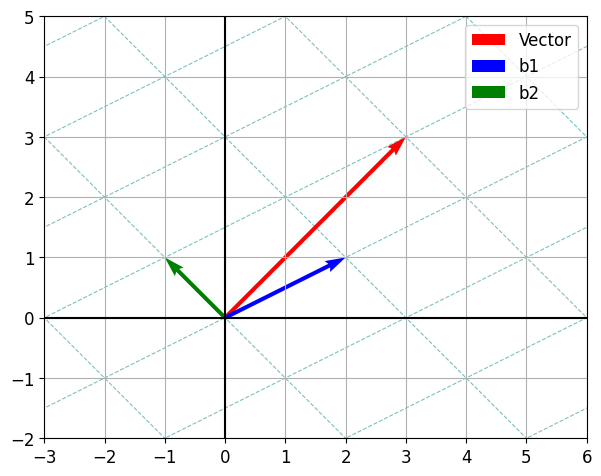

In [7]:
fig, ax = plt.subplots()

xlim, ylim = (-3, 6), (-2, 5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Standard grid + axes
ax.grid(True, zorder=0)
ax.axhline(0, color='black', zorder=2)
ax.axvline(0, color='black', zorder=2)

# New basis grid
i_range, j_range = get_grid_ranges(xlim, ylim, P_inv)
draw_new_basis_grid(ax, b1, b2, i_range, j_range)

# Vector
ax.quiver(0,0,v[0],v[1],
          angles='xy', scale_units='xy', scale=1,
          color='red', label='Vector')

# Basis vectors
ax.quiver(0,0,b1[0],b1[1],
          angles='xy', scale_units='xy', scale=1,
          color='blue', label='b1')

ax.quiver(0,0,b2[0],b2[1],
          angles='xy', scale_units='xy', scale=1,
          color='green', label='b2')

ax.set_aspect('equal')
ax.legend()

plt.show()

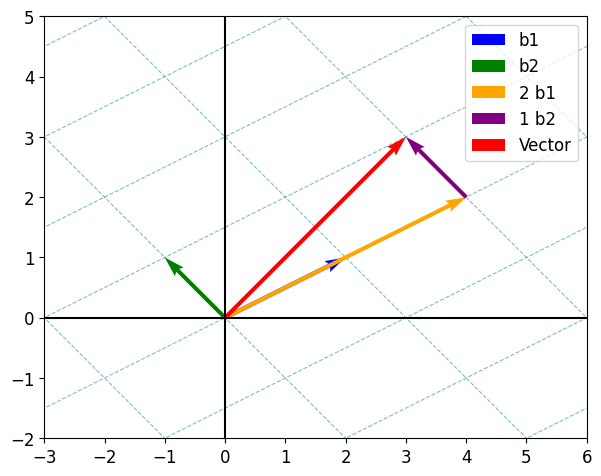

In [8]:
fig, ax = plt.subplots()

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.axhline(0, color='black', zorder=2)
ax.axvline(0, color='black', zorder=2)

# New basis grid
draw_new_basis_grid(ax, b1, b2, i_range, j_range)

# Draw basis vectors
ax.quiver(0,0,b1[0],b1[1],
          angles='xy', scale_units='xy', scale=1,
          color='blue', label='b1')

ax.quiver(0,0,b2[0],b2[1],
          angles='xy', scale_units='xy', scale=1,
          color='green', label='b2')

# Component along b1
step1 = v_new[0]*b1

ax.quiver(0,0,
          step1[0],
          step1[1],
          angles='xy', scale_units='xy', scale=1,
          color='orange', label='2 b1')

# Component along b2

step2 = v_new[1]*b2

ax.quiver(step1[0],
          step1[1],
          step2[0],
          step2[1],
          angles='xy', scale_units='xy', scale=1,
          color='purple', label='1 b2')

# Final vector

ax.quiver(0,0,
          v[0],
          v[1],
          angles='xy', scale_units='xy', scale=1,
          color='red',
          linewidth=3,
          label='Vector')

ax.set_aspect('equal')
ax.legend()

plt.show()

In [9]:
print("="*50)

print("STANDARD BASIS VECTOR")
print(v)

print("\nNEW BASIS")
print("b1 =",b1)
print("b2 =",b2)

print("\nBasis Matrix")
print(P)

print("\nInverse Basis Matrix")
print(P_inv)

print("\nCoordinates in New Basis")
print(v_new)

print("\nVerification")
print(P @ v_new)

print("="*50)

STANDARD BASIS VECTOR
[3 3]

NEW BASIS
b1 = [2 1]
b2 = [-1  1]

Basis Matrix
[[ 2 -1]
 [ 1  1]]

Inverse Basis Matrix
[[ 0.33333333  0.33333333]
 [-0.33333333  0.66666667]]

Coordinates in New Basis
[2. 1.]

Verification
[3. 3.]
